🚀 Inizio elaborazione tracce Jaeger...
Elaborazione di 1000 tracce...

Request 1 (Trace 1819510c...):
  Root span duration: 2.48ms
  Span 5 method duration: 28.03ms
  Tempo fino a span 5: 27.86ms
  Durata span 5: 0.17ms

Request 2 (Trace 61ebacb1...):
  Root span duration: 2.58ms
  Span 5 method duration: 28.63ms
  Tempo fino a span 5: 27.65ms
  Durata span 5: 0.98ms

Request 3 (Trace fe211f9a...):
  Root span duration: 2.46ms
  Span 5 method duration: 25.36ms
  Tempo fino a span 5: 24.49ms
  Durata span 5: 0.87ms

Dati processati:
Tracce totali: 1000
Tracce valide: 1000

=== ANALISI  ===
Numero di tracce: 1000
Durata media: 4.96ms
Durata mediana: 4.15ms
Durata minima: 2.95ms
Durata massima: 48.85ms
Deviazione standard: 3.79ms
Outliers rimossi: 73 (7.3%)
Range valido: 2.34ms - 6.18ms

=== DOPO RIMOZIONE OUTLIERS ===
Numero di tracce: 927
Durata media: 4.23ms
Durata mediana: 4.09ms
Durata minima: 2.95ms
Durata massima: 6.16ms


/tmp/ipykernel_101084/1232514546.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=['Originali', 'Filtrati'])


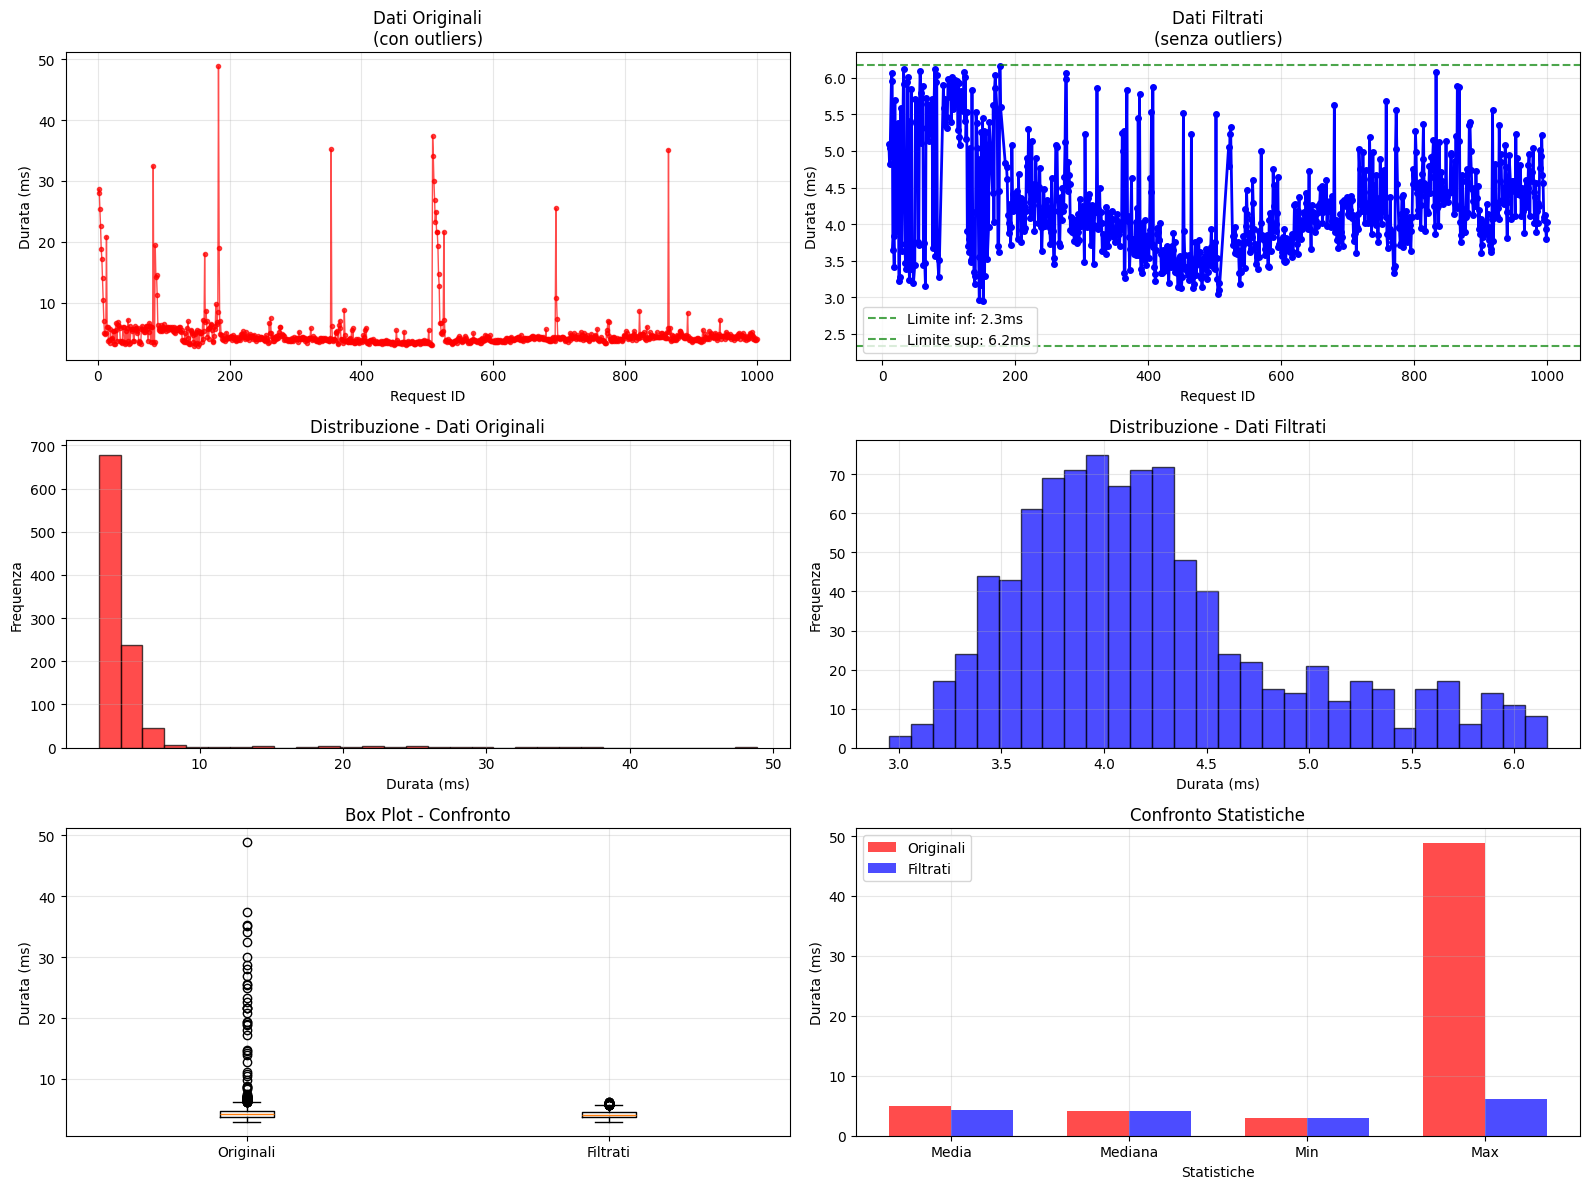


✅ Analisi completata!
📊 File salvati: trace_analysis_original.csv, trace_analysis_filtered.csv


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def get_trace_duration_from_root(spans):
    """
    Trova il root span e restituisce la sua durata
    """
    for span in spans:
        if not span.get('parentSpanID') or span.get('parentSpanID') == '':
            return span['duration']  # Durata in microsecondi
    return None

def calculate_duration_with_span5(spans):
    """
    Calcola la durata come: (inizio traccia - inizio span 5) + durata span 5
    """
    if len(spans) < 6:  # Verifica che esista lo span 5 (indice 5)
        return None
    
    # Trova il tempo di inizio più precoce (inizio traccia)
    trace_start = min(span['startTime'] for span in spans)
    
    # Prendi lo span 5 (indice 5)
    span_5 = spans[5]
    span_5_start = span_5['startTime']
    span_5_duration = span_5['duration']
    
    # Calcola: (tempo fino a span 5) + durata span 5
    duration = (span_5_start - trace_start) + span_5_duration
    
    return duration

def remove_outliers(df, column):
    """
    Rimuove outlier usando il metodo IQR (Interquartile Range)
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definisce i limiti (1.5 * IQR è il metodo standard)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtra i dati
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].copy()
    
    outliers_count = len(df) - len(filtered_df)
    print(f"Outliers rimossi: {outliers_count} ({outliers_count/len(df)*100:.1f}%)")
    print(f"Range valido: {lower_bound:.2f}ms - {upper_bound:.2f}ms")
    
    return filtered_df, lower_bound, upper_bound

def process_trace_file(filename):
    """
    Carica un file JSON di tracce Jaeger ed estrae le durate.
    Restituisce sia i dati originali che quelli filtrati.
    """
    # Carica il file JSON
    with open(filename, 'r') as f:
        data = json.load(f)
    
    print(f"Elaborazione di {len(data['data'])} tracce...")
    
    results = []
    
    # Elabora ogni traccia
    for request_id, trace in enumerate(data['data'], 1):
        trace_id = trace['traceID']
        spans = trace['spans']
        
        # Metodo 1: Durata dal root span
        root_duration = get_trace_duration_from_root(spans)
        
        # Metodo 2: Durata usando span 5
        span5_duration = calculate_duration_with_span5(spans)
        
        # Converti microsecondi in millisecondi
        root_duration_ms = root_duration / 1000 if root_duration else None
        span5_duration_ms = span5_duration / 1000 if span5_duration else None
        
        # Debug info per alcune tracce
        if request_id <= 3:  # Solo prime 3 per non intasare l'output
            print(f"\nRequest {request_id} (Trace {trace_id[:8]}...):")
            print(f"  Root span duration: {root_duration_ms:.2f}ms")
            print(f"  Span 5 method duration: {span5_duration_ms:.2f}ms" if span5_duration_ms else "  Span 5 method: N/A")
            
            if len(spans) >= 6:
                span_5 = spans[5]
                trace_start = min(span['startTime'] for span in spans)
                time_to_span5 = (span_5['startTime'] - trace_start) / 1000
                span5_own_duration = span_5['duration'] / 1000
                print(f"  Tempo fino a span 5: {time_to_span5:.2f}ms")
                print(f"  Durata span 5: {span5_own_duration:.2f}ms")
        
        # Salva i risultati
        results.append({
            'request_id': request_id,
            'traceID': trace_id,
            'root_duration_ms': root_duration_ms,
            'span5_method_duration_ms': span5_duration_ms,
            'total_duration_ms': span5_duration_ms or root_duration_ms  # Preferisce metodo span 5
        })
    
    # Crea DataFrame
    df = pd.DataFrame(results)
    
    # Rimuovi righe con valori nulli
    df_clean = df.dropna(subset=['total_duration_ms'])
    
    print(f"\nDati processati:")
    print(f"Tracce totali: {len(df)}")
    print(f"Tracce valide: {len(df_clean)}")
    
    return df_clean

def analyze_and_plot(df, title_suffix=""):
    """
    Analizza i dati e crea i grafici
    """
    print(f"\n=== ANALISI {title_suffix.upper()} ===")
    
    # Statistiche di base
    print(f"Numero di tracce: {len(df)}")
    print(f"Durata media: {df['total_duration_ms'].mean():.2f}ms")
    print(f"Durata mediana: {df['total_duration_ms'].median():.2f}ms")
    print(f"Durata minima: {df['total_duration_ms'].min():.2f}ms")
    print(f"Durata massima: {df['total_duration_ms'].max():.2f}ms")
    print(f"Deviazione standard: {df['total_duration_ms'].std():.2f}ms")
    
    # Rimuovi outliers
    df_filtered, lower_bound, upper_bound = remove_outliers(df, 'total_duration_ms')
    
    print(f"\n=== DOPO RIMOZIONE OUTLIERS ===")
    print(f"Numero di tracce: {len(df_filtered)}")
    print(f"Durata media: {df_filtered['total_duration_ms'].mean():.2f}ms")
    print(f"Durata mediana: {df_filtered['total_duration_ms'].median():.2f}ms")
    print(f"Durata minima: {df_filtered['total_duration_ms'].min():.2f}ms")
    print(f"Durata massima: {df_filtered['total_duration_ms'].max():.2f}ms")
    
    # Crea i grafici
    plt.figure(figsize=(16, 12))
    
    # Grafico 1: Dati originali
    plt.subplot(3, 2, 1)
    plt.plot(df['request_id'], df['total_duration_ms'], 'r-o', 
             linewidth=1, markersize=3, alpha=0.7)
    plt.xlabel('Request ID')
    plt.ylabel('Durata (ms)')
    plt.title(f'Dati Originali{title_suffix}\n(con outliers)')
    plt.grid(True, alpha=0.3)
    
    # Grafico 2: Dati filtrati
    plt.subplot(3, 2, 2)
    plt.plot(df_filtered['request_id'], df_filtered['total_duration_ms'], 
             'b-o', linewidth=2, markersize=4)
    plt.axhline(y=lower_bound, color='g', linestyle='--', alpha=0.7, 
                label=f'Limite inf: {lower_bound:.1f}ms')
    plt.axhline(y=upper_bound, color='g', linestyle='--', alpha=0.7, 
                label=f'Limite sup: {upper_bound:.1f}ms')
    plt.xlabel('Request ID')
    plt.ylabel('Durata (ms)')
    plt.title(f'Dati Filtrati{title_suffix}\n(senza outliers)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Grafico 3: Istogramma originali
    plt.subplot(3, 2, 3)
    plt.hist(df['total_duration_ms'], bins=30, alpha=0.7, color='red', 
             edgecolor='black')
    plt.xlabel('Durata (ms)')
    plt.ylabel('Frequenza')
    plt.title('Distribuzione - Dati Originali')
    plt.grid(True, alpha=0.3)
    
    # Grafico 4: Istogramma filtrati
    plt.subplot(3, 2, 4)
    plt.hist(df_filtered['total_duration_ms'], bins=30, alpha=0.7, color='blue', 
             edgecolor='black')
    plt.xlabel('Durata (ms)')
    plt.ylabel('Frequenza')
    plt.title('Distribuzione - Dati Filtrati')
    plt.grid(True, alpha=0.3)
    
    # Grafico 5: Box plot confronto
    plt.subplot(3, 2, 5)
    box_data = [df['total_duration_ms'], df_filtered['total_duration_ms']]
    plt.boxplot(box_data, labels=['Originali', 'Filtrati'])
    plt.ylabel('Durata (ms)')
    plt.title('Box Plot - Confronto')
    plt.grid(True, alpha=0.3)
    
    # Grafico 6: Statistiche riassuntive
    plt.subplot(3, 2, 6)
    categories = ['Media', 'Mediana', 'Min', 'Max']
    original_stats = [df['total_duration_ms'].mean(), df['total_duration_ms'].median(),
                     df['total_duration_ms'].min(), df['total_duration_ms'].max()]
    filtered_stats = [df_filtered['total_duration_ms'].mean(), df_filtered['total_duration_ms'].median(),
                     df_filtered['total_duration_ms'].min(), df_filtered['total_duration_ms'].max()]
    
    x = range(len(categories))
    width = 0.35
    plt.bar([i - width/2 for i in x], original_stats, width, 
            label='Originali', color='red', alpha=0.7)
    plt.bar([i + width/2 for i in x], filtered_stats, width, 
            label='Filtrati', color='blue', alpha=0.7)
    plt.xlabel('Statistiche')
    plt.ylabel('Durata (ms)')
    plt.title('Confronto Statistiche')
    plt.xticks(x, categories)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df_filtered

def main():
    """
    Funzione principale per eseguire l'analisi completa
    """
    filename = 'traces-1755701459390.json'
    
    try:
        # Processa il file di tracce
        print("🚀 Inizio elaborazione tracce Jaeger...")
        df_original = process_trace_file(filename)
        
        # Analizza e crea grafici
        df_filtered = analyze_and_plot(df_original)
        
        # Salva risultati (opzionale)
        df_original.to_csv('trace_analysis_original.csv', index=False)
        df_filtered.to_csv('trace_analysis_filtered.csv', index=False)
        print(f"\n✅ Analisi completata!")
        print(f"📊 File salvati: trace_analysis_original.csv, trace_analysis_filtered.csv")
        
        return df_original, df_filtered
        
    except FileNotFoundError:
        print(f"❌ File '{filename}' non trovato. Verifica il nome e il percorso.")
        return None, None
    except json.JSONDecodeError:
        print(f"❌ Errore nel parsing del JSON. Verifica che il file sia valido.")
        return None, None
    except Exception as e:
        print(f"❌ Errore imprevisto: {e}")
        return None, None

# Esegui l'analisi
if __name__ == "__main__":
    df_original, df_filtered = main()

🚀 Inizio elaborazione tracce Jaeger...
Elaborazione di 1000 tracce...

Request 1 (Trace 1819510c...):
  Root span duration: 2.48ms
  Span 5 method duration: 28.03ms
  Tempo fino a span 5: 27.86ms
  Durata span 5: 0.17ms

Request 2 (Trace 61ebacb1...):
  Root span duration: 2.58ms
  Span 5 method duration: 28.63ms
  Tempo fino a span 5: 27.65ms
  Durata span 5: 0.98ms

Request 3 (Trace fe211f9a...):
  Root span duration: 2.46ms
  Span 5 method duration: 25.36ms
  Tempo fino a span 5: 24.49ms
  Durata span 5: 0.87ms

Dati processati:
Tracce totali: 1000
Tracce valide: 1000

=== ANALISI  ===
Numero di tracce originali: 1000
Durata media originale: 4.96ms
Durata mediana originale: 4.15ms
Outliers rimossi: 73 (7.3%)
Range valido: 2.34ms - 6.18ms

=== DATI FILTRATI (SENZA OUTLIERS) ===
Numero di tracce: 927
Durata media: 4.23ms
Durata mediana: 4.09ms
Durata minima: 2.95ms
Durata massima: 6.16ms


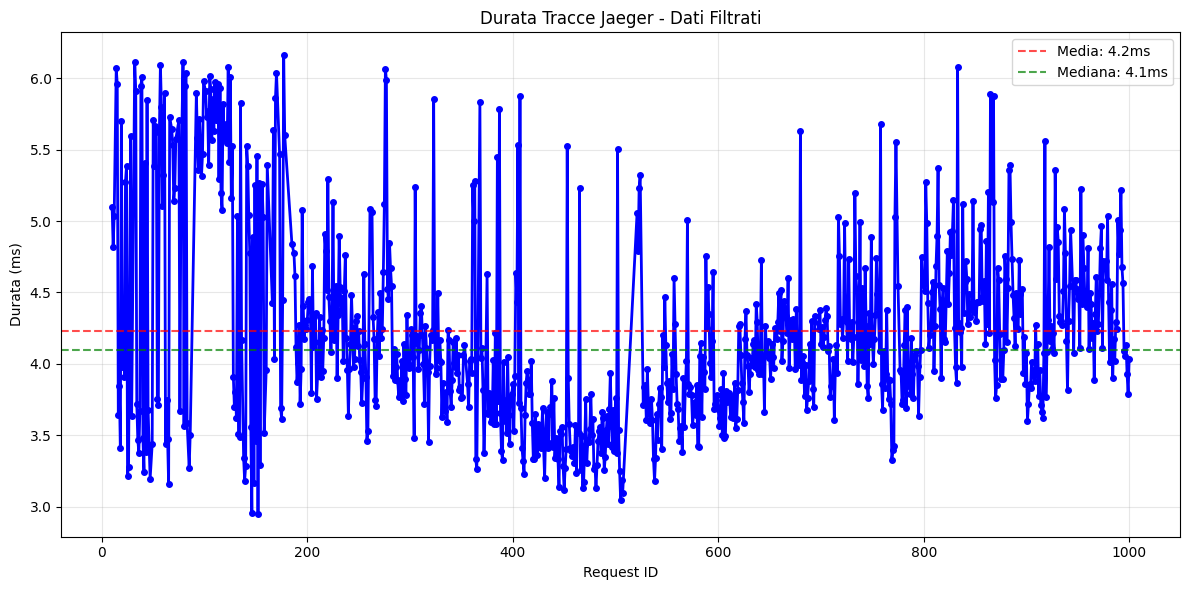


✅ Analisi completata!
📊 File salvati: trace_analysis_original.csv, trace_analysis_filtered.csv


In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def get_trace_duration_from_root(spans):
    """
    Trova il root span e restituisce la sua durata
    """
    for span in spans:
        if not span.get('parentSpanID') or span.get('parentSpanID') == '':
            return span['duration']  # Durata in microsecondi
    return None

def calculate_duration_with_span5(spans):
    """
    Calcola la durata come: (inizio traccia - inizio span 5) + durata span 5
    """
    if len(spans) < 6:  # Verifica che esista lo span 5 (indice 5)
        return None
    
    # Trova il tempo di inizio più precoce (inizio traccia)
    trace_start = min(span['startTime'] for span in spans)
    
    # Prendi lo span 5 (indice 5)
    span_5 = spans[5]
    span_5_start = span_5['startTime']
    span_5_duration = span_5['duration']
    
    # Calcola: (tempo fino a span 5) + durata span 5
    duration = (span_5_start - trace_start) + span_5_duration
    
    return duration

def remove_outliers(df, column):
    """
    Rimuove outlier usando il metodo IQR (Interquartile Range)
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definisce i limiti (1.5 * IQR è il metodo standard)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtra i dati
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].copy()
    
    outliers_count = len(df) - len(filtered_df)
    print(f"Outliers rimossi: {outliers_count} ({outliers_count/len(df)*100:.1f}%)")
    print(f"Range valido: {lower_bound:.2f}ms - {upper_bound:.2f}ms")
    
    return filtered_df, lower_bound, upper_bound

def process_trace_file(filename):
    """
    Carica un file JSON di tracce Jaeger ed estrae le durate.
    Restituisce sia i dati originali che quelli filtrati.
    """
    # Carica il file JSON
    with open(filename, 'r') as f:
        data = json.load(f)
    
    print(f"Elaborazione di {len(data['data'])} tracce...")
    
    results = []
    
    # Elabora ogni traccia
    for request_id, trace in enumerate(data['data'], 1):
        trace_id = trace['traceID']
        spans = trace['spans']
        
        # Metodo 1: Durata dal root span
        root_duration = get_trace_duration_from_root(spans)
        
        # Metodo 2: Durata usando span 5
        span5_duration = calculate_duration_with_span5(spans)
        
        # Converti microsecondi in millisecondi
        root_duration_ms = root_duration / 1000 if root_duration else None
        span5_duration_ms = span5_duration / 1000 if span5_duration else None
        
        # Debug info per alcune tracce
        if request_id <= 3:  # Solo prime 3 per non intasare l'output
            print(f"\nRequest {request_id} (Trace {trace_id[:8]}...):")
            print(f"  Root span duration: {root_duration_ms:.2f}ms")
            print(f"  Span 5 method duration: {span5_duration_ms:.2f}ms" if span5_duration_ms else "  Span 5 method: N/A")
            
            if len(spans) >= 6:
                span_5 = spans[5]
                trace_start = min(span['startTime'] for span in spans)
                time_to_span5 = (span_5['startTime'] - trace_start) / 1000
                span5_own_duration = span_5['duration'] / 1000
                print(f"  Tempo fino a span 5: {time_to_span5:.2f}ms")
                print(f"  Durata span 5: {span5_own_duration:.2f}ms")
        
        # Salva i risultati
        results.append({
            'request_id': request_id,
            'traceID': trace_id,
            'root_duration_ms': root_duration_ms,
            'span5_method_duration_ms': span5_duration_ms,
            'total_duration_ms': span5_duration_ms or root_duration_ms  # Preferisce metodo span 5
        })
    
    # Crea DataFrame
    df = pd.DataFrame(results)
    
    # Rimuovi righe con valori nulli
    df_clean = df.dropna(subset=['total_duration_ms'])
    
    print(f"\nDati processati:")
    print(f"Tracce totali: {len(df)}")
    print(f"Tracce valide: {len(df_clean)}")
    
    return df_clean

def analyze_and_plot_filtered_only(df, title_suffix=""):
    """
    Analizza i dati e crea solo il grafico a linee per i dati filtrati (senza outliers)
    """
    print(f"\n=== ANALISI {title_suffix.upper()} ===")
    
    # Statistiche di base sui dati originali
    print(f"Numero di tracce originali: {len(df)}")
    print(f"Durata media originale: {df['total_duration_ms'].mean():.2f}ms")
    print(f"Durata mediana originale: {df['total_duration_ms'].median():.2f}ms")
    
    # Rimuovi outliers
    df_filtered, lower_bound, upper_bound = remove_outliers(df, 'total_duration_ms')
    
    print(f"\n=== DATI FILTRATI (SENZA OUTLIERS) ===")
    print(f"Numero di tracce: {len(df_filtered)}")
    print(f"Durata media: {df_filtered['total_duration_ms'].mean():.2f}ms")
    print(f"Durata mediana: {df_filtered['total_duration_ms'].median():.2f}ms")
    print(f"Durata minima: {df_filtered['total_duration_ms'].min():.2f}ms")
    print(f"Durata massima: {df_filtered['total_duration_ms'].max():.2f}ms")
    
    # Crea solo il grafico a linee
    plt.figure(figsize=(12, 6))
    plt.plot(df_filtered['request_id'], df_filtered['total_duration_ms'], 
             'b-o', linewidth=2, markersize=4)
    plt.axhline(y=df_filtered['total_duration_ms'].mean(), color='r', 
                linestyle='--', alpha=0.7, label=f'Media: {df_filtered["total_duration_ms"].mean():.1f}ms')
    plt.axhline(y=df_filtered['total_duration_ms'].median(), color='g', 
                linestyle='--', alpha=0.7, label=f'Mediana: {df_filtered["total_duration_ms"].median():.1f}ms')
    plt.xlabel('Request ID')
    plt.ylabel('Durata (ms)')
    plt.title(f'Durata Tracce Jaeger - Dati Filtrati{title_suffix}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return df_filtered

def main():
    """
    Funzione principale per eseguire l'analisi completa
    """
    filename = 'traces-1755701459390.json'
    
    try:
        # Processa il file di tracce
        print("🚀 Inizio elaborazione tracce Jaeger...")
        df_original = process_trace_file(filename)
        
        # Analizza e crea grafici solo per i dati filtrati
        df_filtered = analyze_and_plot_filtered_only(df_original)
        
        # Salva risultati (opzionale)
        df_original.to_csv('trace_analysis_original.csv', index=False)
        df_filtered.to_csv('trace_analysis_filtered.csv', index=False)
        print(f"\n✅ Analisi completata!")
        print(f"📊 File salvati: trace_analysis_original.csv, trace_analysis_filtered.csv")
        
        return df_original, df_filtered
        
    except FileNotFoundError:
        print(f"❌ File '{filename}' non trovato. Verifica il nome e il percorso.")
        return None, None
    except json.JSONDecodeError:
        print(f"❌ Errore nel parsing del JSON. Verifica che il file sia valido.")
        return None, None
    except Exception as e:
        print(f"❌ Errore imprevisto: {e}")
        return None, None

# Esegui l'analisi
if __name__ == "__main__":
    df_original, df_filtered = main()

🚀 Inizio elaborazione tracce Jaeger...
Elaborazione di 1000 tracce...

Request 1 (Trace 1819510c...):
  Root span duration: 2.48ms
  Span 5 method duration: 28.03ms
  Tempo fino a span 5: 27.86ms
  Durata span 5: 0.17ms

Request 2 (Trace 61ebacb1...):
  Root span duration: 2.58ms
  Span 5 method duration: 28.63ms
  Tempo fino a span 5: 27.65ms
  Durata span 5: 0.98ms

Request 3 (Trace fe211f9a...):
  Root span duration: 2.46ms
  Span 5 method duration: 25.36ms
  Tempo fino a span 5: 24.49ms
  Durata span 5: 0.87ms

Dati processati:
Tracce totali: 1000
Tracce valide: 1000

=== ANALISI  ===
Numero di tracce originali: 1000
Durata media originale: 4.96ms
Durata mediana originale: 4.15ms
Outliers rimossi: 73 (7.3%)
Range valido: 2.34ms - 6.18ms

=== DATI FILTRATI (SENZA OUTLIERS) ===
Numero di tracce: 927
Durata media: 4.23ms
Durata mediana: 4.09ms
Durata minima: 2.95ms
Durata massima: 6.16ms
Smoothing applicato con finestra di 10 punti


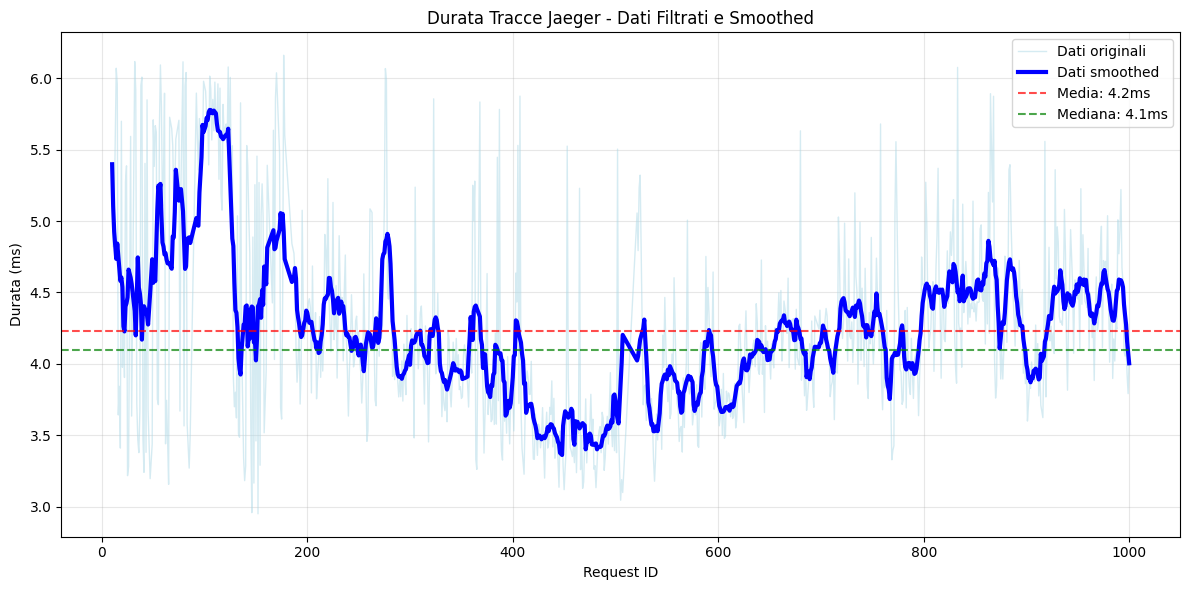


✅ Analisi completata!


In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def get_trace_duration_from_root(spans):
    """
    Trova il root span e restituisce la sua durata
    """
    for span in spans:
        if not span.get('parentSpanID') or span.get('parentSpanID') == '':
            return span['duration']  # Durata in microsecondi
    return None

def calculate_duration_with_span5(spans):
    """
    Calcola la durata come: (inizio traccia - inizio span 5) + durata span 5
    """
    if len(spans) < 6:  # Verifica che esista lo span 5 (indice 5)
        return None
    
    # Trova il tempo di inizio più precoce (inizio traccia)
    trace_start = min(span['startTime'] for span in spans)
    
    # Prendi lo span 5 (indice 5)
    span_5 = spans[5]
    span_5_start = span_5['startTime']
    span_5_duration = span_5['duration']
    
    # Calcola: (tempo fino a span 5) + durata span 5
    duration = (span_5_start - trace_start) + span_5_duration
    
    return duration

def remove_outliers(df, column):
    """
    Rimuove outlier usando il metodo IQR (Interquartile Range)
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definisce i limiti (1.5 * IQR è il metodo standard)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtra i dati
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].copy()
    
    outliers_count = len(df) - len(filtered_df)
    print(f"Outliers rimossi: {outliers_count} ({outliers_count/len(df)*100:.1f}%)")
    print(f"Range valido: {lower_bound:.2f}ms - {upper_bound:.2f}ms")
    
    return filtered_df, lower_bound, upper_bound

def process_trace_file(filename):
    """
    Carica un file JSON di tracce Jaeger ed estrae le durate.
    """
    # Carica il file JSON
    with open(filename, 'r') as f:
        data = json.load(f)
    
    print(f"Elaborazione di {len(data['data'])} tracce...")
    
    results = []
    
    # Elabora ogni traccia
    for request_id, trace in enumerate(data['data'], 1):
        trace_id = trace['traceID']
        spans = trace['spans']
        
        # Metodo 1: Durata dal root span
        root_duration = get_trace_duration_from_root(spans)
        
        # Metodo 2: Durata usando span 5
        span5_duration = calculate_duration_with_span5(spans)
        
        # Converti microsecondi in millisecondi
        root_duration_ms = root_duration / 1000 if root_duration else None
        span5_duration_ms = span5_duration / 1000 if span5_duration else None
        
        # Debug info per alcune tracce
        if request_id <= 3:  # Solo prime 3 per non intasare l'output
            print(f"\nRequest {request_id} (Trace {trace_id[:8]}...):")
            print(f"  Root span duration: {root_duration_ms:.2f}ms")
            print(f"  Span 5 method duration: {span5_duration_ms:.2f}ms" if span5_duration_ms else "  Span 5 method: N/A")
            
            if len(spans) >= 6:
                span_5 = spans[5]
                trace_start = min(span['startTime'] for span in spans)
                time_to_span5 = (span_5['startTime'] - trace_start) / 1000
                span5_own_duration = span_5['duration'] / 1000
                print(f"  Tempo fino a span 5: {time_to_span5:.2f}ms")
                print(f"  Durata span 5: {span5_own_duration:.2f}ms")
        
        # Salva i risultati
        results.append({
            'request_id': request_id,
            'traceID': trace_id,
            'root_duration_ms': root_duration_ms,
            'span5_method_duration_ms': span5_duration_ms,
            'total_duration_ms': span5_duration_ms or root_duration_ms  # Preferisce metodo span 5
        })
    
    # Crea DataFrame
    df = pd.DataFrame(results)
    
    # Rimuovi righe con valori nulli
    df_clean = df.dropna(subset=['total_duration_ms'])
    
    print(f"\nDati processati:")
    print(f"Tracce totali: {len(df)}")
    print(f"Tracce valide: {len(df_clean)}")
    
    return df_clean

def analyze_and_plot_filtered_only(df, title_suffix="", window_size=10):
    """
    Analizza i dati e crea solo il grafico a linee per i dati filtrati (senza outliers)
    con smoothing tramite media mobile
    """
    print(f"\n=== ANALISI {title_suffix.upper()} ===")
    
    # Statistiche di base sui dati originali
    print(f"Numero di tracce originali: {len(df)}")
    print(f"Durata media originale: {df['total_duration_ms'].mean():.2f}ms")
    print(f"Durata mediana originale: {df['total_duration_ms'].median():.2f}ms")
    
    # Rimuovi outliers
    df_filtered, lower_bound, upper_bound = remove_outliers(df, 'total_duration_ms')
    
    print(f"\n=== DATI FILTRATI (SENZA OUTLIERS) ===")
    print(f"Numero di tracce: {len(df_filtered)}")
    print(f"Durata media: {df_filtered['total_duration_ms'].mean():.2f}ms")
    print(f"Durata mediana: {df_filtered['total_duration_ms'].median():.2f}ms")
    print(f"Durata minima: {df_filtered['total_duration_ms'].min():.2f}ms")
    print(f"Durata massima: {df_filtered['total_duration_ms'].max():.2f}ms")
    
    # Ordina per request_id per assicurarsi che sia in sequenza
    df_sorted = df_filtered.sort_values('request_id').reset_index(drop=True)
    
    # Applica smoothing con media mobile
    df_sorted['smoothed_duration'] = df_sorted['total_duration_ms'].rolling(
        window=window_size, center=True, min_periods=1).mean()
    
    print(f"Smoothing applicato con finestra di {window_size} punti")
    
    # Crea solo il grafico a linee
    plt.figure(figsize=(12, 6))
    
    # Linea originale (più leggera)
    plt.plot(df_sorted['request_id'], df_sorted['total_duration_ms'], 
             'lightblue', linewidth=1, alpha=0.5, label='Dati originali')
    
    # Linea smoothed (principale)
    plt.plot(df_sorted['request_id'], df_sorted['smoothed_duration'], 
             'b-', linewidth=3, label='Dati smoothed')
    
    plt.axhline(y=df_filtered['total_duration_ms'].mean(), color='r', 
                linestyle='--', alpha=0.7, label=f'Media: {df_filtered["total_duration_ms"].mean():.1f}ms')
    plt.axhline(y=df_filtered['total_duration_ms'].median(), color='g', 
                linestyle='--', alpha=0.7, label=f'Mediana: {df_filtered["total_duration_ms"].median():.1f}ms')
    plt.xlabel('Request ID')
    plt.ylabel('Durata (ms)')
    plt.title(f'Durata Tracce Jaeger - Dati Filtrati e Smoothed{title_suffix}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('test-incre.png')
    plt.show()
    
    return df_filtered

def main():
    """
    Funzione principale per eseguire l'analisi completa
    """
    filename = 'traces-1755701459390.json'
    
    try:
        # Processa il file di tracce
        print("🚀 Inizio elaborazione tracce Jaeger...")
        df_original = process_trace_file(filename)
        
        # Analizza e crea grafici solo per i dati filtrati
        df_filtered = analyze_and_plot_filtered_only(df_original)
        
        print(f"\n✅ Analisi completata!")
        
        return df_original, df_filtered
        
    except FileNotFoundError:
        print(f"❌ File '{filename}' non trovato. Verifica il nome e il percorso.")
        return None, None
    except json.JSONDecodeError:
        print(f"❌ Errore nel parsing del JSON. Verifica che il file sia valido.")
        return None, None
    except Exception as e:
        print(f"❌ Errore imprevisto: {e}")
        return None, None

# Esegui l'analisi
if __name__ == "__main__":
    df_original, df_filtered = main()